In [1]:
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import AgglomerativeClustering

from social_graph.describe import persona_significance
from social_graph.pipeline import *
from social_graph.preprocessing import *
from social_graph.metrics import *
from social_graph.analysis import *

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\magda\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [2]:
conn = sqlite3.connect('data/exp_set_2/database_server.db')

## Personality-based persona & basic analysis pipeline

Data loading ...

Number of users: 1000
Total actions: 20653
Follow actions: 19661
Unfollow actions: 992
Number of rounds: 51
Number of posts: 155568

Checking professions consistency ...

Number of professions not in map: 0
Professions: set()

Creating persona and features DataFrames ...

Features encoded size: (1000, 10)

Searching best number of persona ...

k=2 silhouette=0.1720
k=3 silhouette=0.1729
k=4 silhouette=0.2169
k=5 silhouette=0.2234
k=6 silhouette=0.2516
k=7 silhouette=0.2478
k=8 silhouette=0.2728
k=9 silhouette=0.3159


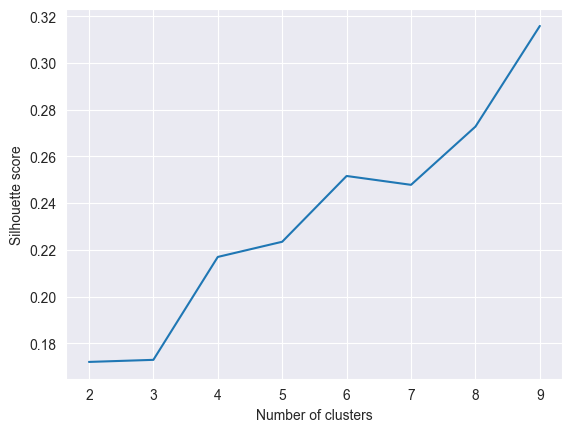


Done!


In [3]:
features_cols = ['openness', 'conscientiousness', 'extroversion', 'agreeableness', 'neuroticism']
personas, features_df, follow = run_simulation_preprocessing(conn, feature_cols=features_cols)

Persona creation ...

persona
Persona_1    234
Persona_2    186
Persona_6    158
Persona_3    156
Persona_4    150
Persona_5    116
Name: count, dtype: int64

Persona analysis ...

Features significance regarding personae:
openness: 1.2307801955218897e-54
conscientiousness: 4.9913527424962484e-83
extroversion: 2.390919307008131e-122
agreeableness: 5.636350347714726e-110
neuroticism: 3.4064796296913e-113


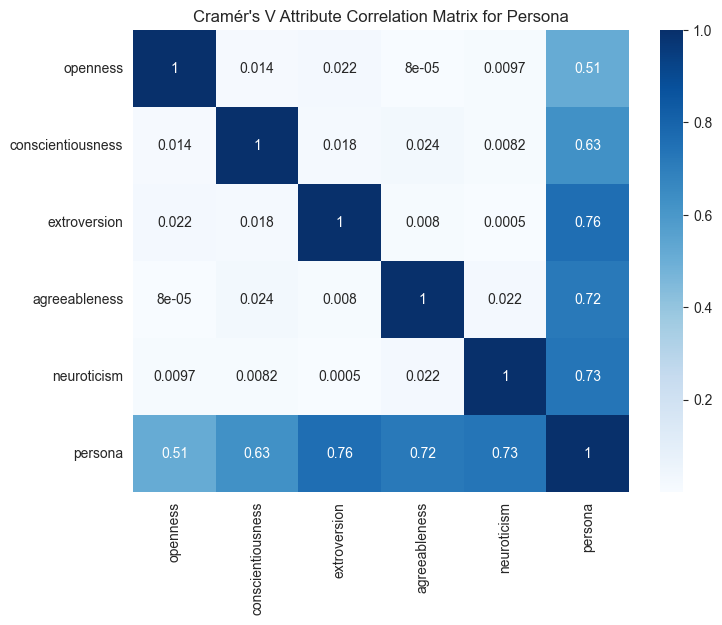

In [4]:
k_best = 6
description, persona_dict = cluster_persona_and_analyse(personas, features_df, k_best, feature_cols=features_cols)

In [5]:
description

,consistent/cautious,inventive/curious,efficient/organized,extravagant/careless,outgoing/energetic,solitary/reserved,critical/judgmental,friendly/compassionate,resilient/confident,sensitive/nervous
persona,,,,,,,,,,
Persona_1,0.722222,0.277778,0.713675,0.286325,0.846154,0.153846,0.854701,0.145299,0.136752,0.863248
Persona_2,0.543011,0.456989,0.000000,1.000000,0.854839,0.145161,0.333333,0.666667,0.827957,0.172043
Persona_3,0.423077,0.576923,0.365385,0.634615,0.211538,0.788462,0.000000,1.000000,0.000000,1.000000
Persona_4,0.233333,0.766667,1.000000,0.000000,0.773333,0.226667,0.166667,0.833333,0.786667,0.213333
Persona_5,1.000000,0.000000,0.500000,0.500000,0.000000,1.000000,0.482759,0.517241,1.000000,0.000000
Persona_6,0.208861,0.791139,0.417722,0.582278,0.000000,1.000000,1.000000,0.000000,0.373418,0.626582


In [6]:
global_metrics, summary = build_graph_and_analyse(follow, persona_dict)

Graph creation ...

Number of nodes: 983
Number of edges: 18691
Number of connective components: 3
Components sizes: [981, 1, 1]
Number of nodes (LCC): 981
Number of edges (LCC): 18691

Global metrics ...

Mean degree: 38.03
Density: 0.0194
Diameter: 5
Avg. shortest path: 2.510
Modularity score: 0.141
Persona assortativity: 0.000710531767175331

Local metrics ...


Statistical check (metrics vs. persona) ...

in_degree statistics: p = 0.2579
out_degree statistics: p = 0.3330
total_degree statistics: p = 0.3233
betweenness statistics: p = 0.4372
eigenvector statistics: p = 0.3288
pagerank statistics: p = 0.3421
kcore statistics: p = 0.3740


In [7]:
global_metrics

,Simulation
Metric,
Mean degree,38.028484
Density,0.019363
Diameter,5.000000
Avg. shortest path,2.509994
Modularity,0.141140
Persona assortativity,0.000711


In [8]:
summary

,n_nodes,mean_in_degree,mean_out_degree,mean_total_degree,mean_betweenness,median_betweenness,mean_eigenvector,mean_pagerank,mean_kcore,pagerank_ratio
persona,,,,,,,,,,
Persona_1,228,17.653509,17.732456,35.385965,0.001361,0.000171,0.017503,0.000953,16.311404,0.935092
Persona_2,183,17.743169,16.945355,34.688525,0.001499,0.000131,0.017641,0.000969,15.732240,0.950239
Persona_3,153,25.052288,24.124183,49.176471,0.002370,0.000276,0.023867,0.001288,18.444444,1.263995
Persona_4,149,18.402685,17.912752,36.315436,0.001624,0.000166,0.017731,0.000995,15.657718,0.975863
Persona_5,111,18.090090,18.873874,36.963964,0.001461,0.000206,0.018302,0.000974,16.234234,0.955018
Persona_6,157,18.063694,19.694268,37.757962,0.001655,0.000120,0.019423,0.000968,16.057325,0.949704


### Null model validation

In [12]:
G, G_lcc = create_graph(follow)

nx.set_node_attributes(G, persona_dict, "persona")
nx.set_node_attributes(G_lcc, persona_dict, "persona")

Number of nodes: 983
Number of edges: 18691
Number of connective components: 3
Components sizes: [981, 1, 1]
Number of nodes (LCC): 981
Number of edges (LCC): 18691


In [13]:
null_distributions = persona_permutation_test(G_lcc, summary, n_perm=500, seed=42)

In [14]:
p_values = permutation_pvalues(summary, null_distributions) # set a seed in future!!!
p_values

,n_nodes,mean_in_degree,mean_out_degree,mean_total_degree,mean_betweenness,median_betweenness,mean_eigenvector,mean_pagerank,mean_kcore,pagerank_ratio
persona,,,,,,,,,,
Persona_1,1.0,0.806387,0.802395,0.808383,0.898204,0.473054,0.838323,0.824351,0.552894,0.824351
Persona_2,1.0,0.764471,0.888224,0.826347,0.692615,0.776447,0.784431,0.740519,0.794411,0.740519
Persona_3,1.0,0.005988,0.007984,0.005988,0.019960,0.051896,0.007984,0.005988,0.011976,0.005988
Persona_4,1.0,0.600798,0.698603,0.656687,0.487026,0.514970,0.734531,0.584830,0.776447,0.584830
Persona_5,1.0,0.642715,0.518962,0.564870,0.700599,0.223553,0.604790,0.648703,0.526946,0.648703
Persona_6,1.0,0.662675,0.353293,0.495010,0.435130,0.860279,0.377246,0.688623,0.626747,0.688623


In [15]:
z_scores = permutation_zscores(summary, null_distributions)
z_scores

,n_nodes,mean_in_degree,mean_out_degree,mean_total_degree,mean_betweenness,median_betweenness,mean_eigenvector,mean_pagerank,mean_kcore,pagerank_ratio
persona,,,,,,,,,,
Persona_1,0.0,-0.863587,-0.878154,-0.874476,-1.199831,0.019047,-0.998474,-0.910199,-0.130450,-0.910199
Persona_2,0.0,-0.721921,-1.215825,-0.965163,-0.530083,-0.814976,-0.821957,-0.626492,-0.833709,-0.626492
Persona_3,0.0,2.865718,2.609844,2.755612,2.409786,1.939482,2.659790,2.872451,2.225284,2.872451
Persona_4,0.0,-0.311228,-0.583697,-0.445010,-0.069521,-0.081455,-0.658688,-0.262541,-0.757634,-0.262541
Persona_5,0.0,-0.376149,-0.063750,-0.226237,-0.518036,0.474176,-0.273998,-0.402429,-0.106895,-0.402429
Persona_6,0.0,-0.408202,0.402453,-0.019795,0.110398,-0.863842,0.325597,-0.481568,-0.312524,-0.481568


### PCA - Big Five coloured by personas

In [9]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(features_df)

In [10]:
plot_df = pd.DataFrame({
    'PC1': X_pca[:,0],
    'PC2': X_pca[:,1],
    'persona': personas['persona']
})

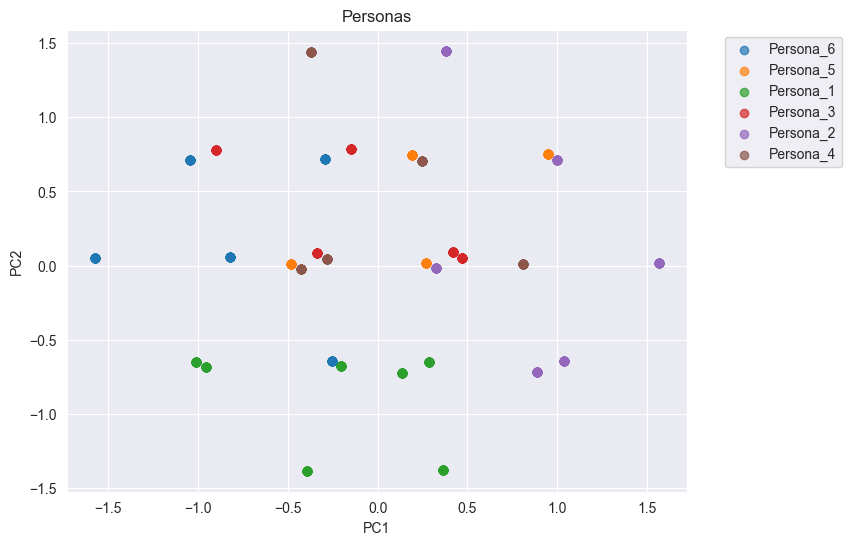

In [11]:
plot_pca(plot_df, colour_by='persona', title='Personas')

## Features engineering

Based on *personas_on_behaviour.ipynb*.

In [17]:
personas = personas[['id', 'persona']].rename(columns={'id': 'follower_id'})

follow = follow.merge(personas, on='follower_id', how='left')
follow.head()

,user_id,follower_id,id,action,round,persona
0,744,856,1,follow,1,Persona_4
1,27,80,2,follow,1,Persona_6
2,529,27,3,follow,1,Persona_1
3,872,911,4,follow,1,Persona_2
4,249,872,5,follow,1,Persona_4


### Lifespan

In [18]:
lifespan = lifespan_analysis(follow, agg_by='follower_id')
lifespan.head()

Invalid unfollow action for users 67 -> 216: unfollow
Invalid unfollow action for users 118 -> 758: unfollow
Invalid unfollow action for users 118 -> 905: unfollow
Invalid unfollow action for users 123 -> 774: unfollow
Invalid unfollow action for users 249 -> 178: unfollow
Invalid unfollow action for users 249 -> 178: unfollow
Invalid unfollow action for users 249 -> 178: unfollow
Invalid unfollow action for users 249 -> 178: unfollow
Invalid unfollow action for users 275 -> 708: unfollow
Invalid unfollow action for users 330 -> 847: unfollow
Invalid unfollow action for users 342 -> 587: unfollow
Invalid unfollow action for users 342 -> 587: unfollow
Invalid unfollow action for users 343 -> 845: unfollow
Invalid unfollow action for users 354 -> 342: unfollow
Invalid unfollow action for users 356 -> 587: unfollow
Invalid unfollow action for users 359 -> 331: unfollow
Invalid unfollow action for users 438 -> 342: unfollow
Invalid unfollow action for users 438 -> 342: unfollow
Invalid unf

,follower_id,total_connections,existing,removed,lifespan_mean,lifespan_std,lifespan_median,survival_rate
0,2,13,13,0,NaN,NaN,NaN,1.000000
1,3,4,4,0,NaN,NaN,NaN,1.000000
2,4,20,20,0,NaN,NaN,NaN,1.000000
3,5,139,130,9,13.319444,18.333558,1.375000,0.935252
4,6,32,30,2,1.020833,1.443676,1.020833,0.937500


### Follow

In [19]:
local_metrics, summary = calculate_local_metrics(G_lcc)
local_metrics.drop(columns=['persona'], inplace=True)
local_metrics.head()

,node,in_degree,out_degree,total_degree,betweenness,eigenvector,pagerank,kcore
0,856,141,114,255,0.016564,0.110036,0.006396,41
1,744,154,143,297,0.024440,0.124465,0.007169,41
2,80,51,53,104,0.004106,0.059890,0.002546,41
3,27,104,102,206,0.014151,0.092359,0.004663,41
4,529,109,99,208,0.013711,0.096607,0.004975,41


<Axes: >

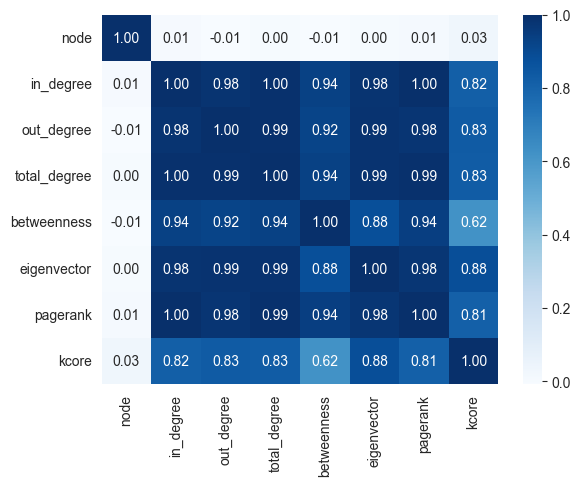

In [20]:
corr = local_metrics.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues')

### Posts

In [21]:
posts = pd.read_sql("SELECT * FROM post", conn)
personas.rename(columns={'follower_id': 'user_id'}, inplace=True)
posts = posts.merge(personas, on='user_id', how='left')

posts = posts.drop_duplicates(
    subset=['user_id', 'tweet', 'round']
)
posts.head()

,id,tweet,post_img,user_id,comment_to,thread_id,round,news_id,shared_from,image_id,reaction_count,persona
0,1,Just finished bingewatching a new series on Ne...,None,961,-1,1,1,None,-1,None,0,Persona_1
1,2,Nothing beats that postworkout feeling! 💪 Just...,None,856,-1,2,1,None,-1,None,0,Persona_4
2,3,Nothing beats that postworkout feeling! 💪 Just...,None,856,-1,3,1,None,-1,None,0,Persona_4
6,7,@AndrewJohnson I'm always looking for a new sh...,None,856,1,1,1,None,-1,None,0,Persona_4
7,8,@AndrewJohnson Still waiting on that title! I'...,None,856,1,1,1,None,-1,None,0,Persona_4


In [22]:
posts_summary = posts_analysis(posts)
posts_summary.head()

,user_id,positive_posts,neutral_posts,negative_posts,total_posts,avg_word_count,persona
0,2,70,0,15,85,25.094118,Persona_6
1,3,22,1,0,23,30.956522,Persona_5
2,4,75,1,2,78,29.038462,Persona_1
3,5,1038,58,69,1165,26.466953,Persona_3
4,6,153,20,25,198,24.606061,Persona_6


### New features

In [24]:
local_metrics.rename(columns={'node': 'user_id'}, inplace=True)
lifespan.rename(columns={'follower_id': 'user_id'}, inplace=True)

personas_features = (lifespan.
               merge(local_metrics, on='user_id').
               merge(posts_summary, on='user_id'))

personas_features.head()

,user_id,total_connections,existing,removed,lifespan_mean,lifespan_std,lifespan_median,survival_rate,in_degree,out_degree,...,betweenness,eigenvector,pagerank,kcore,positive_posts,neutral_posts,negative_posts,total_posts,avg_word_count,persona
0,2,13,13,0,NaN,NaN,NaN,1.000000,12,13,...,5.842536e-05,0.015870,0.000672,19,70,0,15,85,25.094118,Persona_6
1,3,4,4,0,NaN,NaN,NaN,1.000000,1,4,...,4.417667e-07,0.004818,0.000194,5,22,1,0,23,30.956522,Persona_5
2,4,20,20,0,NaN,NaN,NaN,1.000000,7,20,...,1.648232e-04,0.015062,0.000478,19,75,1,2,78,29.038462,Persona_1
3,5,139,130,9,13.319444,18.333558,1.375000,0.935252,130,130,...,2.151160e-02,0.107608,0.005960,41,1038,58,69,1165,26.466953,Persona_3
4,6,32,30,2,1.020833,1.443676,1.020833,0.937500,21,30,...,3.493630e-03,0.025537,0.001311,27,153,20,25,198,24.606061,Persona_6


In [25]:
days = 50

posts_columns = ['positive_posts', 'neutral_posts', 'negative_posts']

for column in posts_columns:
    personas_features[column + '_ratio'] = personas_features[column] / personas_features['total_posts']

personas_features['posts_per_day'] = personas_features['total_posts'] / days

personas_features['in_out_degree_ratio'] = personas_features['in_degree'] / (personas_features['out_degree'] + 1)

personas_features.head()

,user_id,total_connections,existing,removed,lifespan_mean,lifespan_std,lifespan_median,survival_rate,in_degree,out_degree,...,neutral_posts,negative_posts,total_posts,avg_word_count,persona,positive_posts_ratio,neutral_posts_ratio,negative_posts_ratio,posts_per_day,in_out_degree_ratio
0,2,13,13,0,NaN,NaN,NaN,1.000000,12,13,...,0,15,85,25.094118,Persona_6,0.823529,0.000000,0.176471,1.70,0.857143
1,3,4,4,0,NaN,NaN,NaN,1.000000,1,4,...,1,0,23,30.956522,Persona_5,0.956522,0.043478,0.000000,0.46,0.200000
2,4,20,20,0,NaN,NaN,NaN,1.000000,7,20,...,1,2,78,29.038462,Persona_1,0.961538,0.012821,0.025641,1.56,0.333333
3,5,139,130,9,13.319444,18.333558,1.375000,0.935252,130,130,...,58,69,1165,26.466953,Persona_3,0.890987,0.049785,0.059227,23.30,0.992366
4,6,32,30,2,1.020833,1.443676,1.020833,0.937500,21,30,...,20,25,198,24.606061,Persona_6,0.772727,0.101010,0.126263,3.96,0.677419


In [52]:
selected_features = personas_features[['user_id', 'persona', 'in_out_degree_ratio', 'betweenness', 'kcore',
                    'neutral_posts_ratio', 'negative_posts_ratio', 'posts_per_day', 'lifespan_mean', 'survival_rate', 'avg_word_count']]

selected_features.set_index('user_id', inplace=True)
selected_features.head()

,persona,in_out_degree_ratio,betweenness,kcore,neutral_posts_ratio,negative_posts_ratio,posts_per_day,lifespan_mean,survival_rate,avg_word_count
user_id,,,,,,,,,,
2,Persona_6,0.857143,5.842536e-05,19,0.000000,0.176471,1.70,NaN,1.000000,25.094118
3,Persona_5,0.200000,4.417667e-07,5,0.043478,0.000000,0.46,NaN,1.000000,30.956522
4,Persona_1,0.333333,1.648232e-04,19,0.012821,0.025641,1.56,NaN,1.000000,29.038462
5,Persona_3,0.992366,2.151160e-02,41,0.049785,0.059227,23.30,13.319444,0.935252,26.466953
6,Persona_6,0.677419,3.493630e-03,27,0.101010,0.126263,3.96,1.020833,0.937500,24.606061


<Axes: >

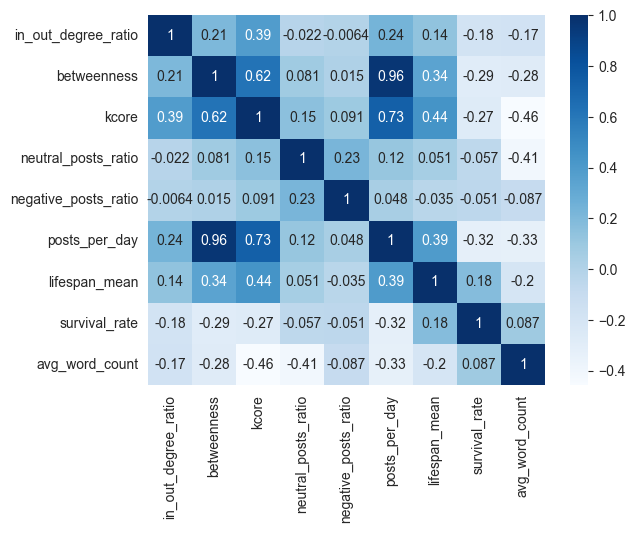

In [53]:
corr = selected_features.drop(columns=['persona'], inplace=False).corr()
sns.heatmap(corr, annot=True, cmap='Blues')

## Old persona vs. behavioral features

In [54]:
selected_features.groupby('persona').mean()

,in_out_degree_ratio,betweenness,kcore,neutral_posts_ratio,negative_posts_ratio,posts_per_day,lifespan_mean,survival_rate,avg_word_count
persona,,,,,,,,,
Persona_1,0.841252,0.001423,16.986239,0.055433,0.120497,2.903119,4.956564,0.979509,28.656576
Persona_2,0.861952,0.001516,15.895028,0.034730,0.112633,2.779116,4.720070,0.975123,30.148221
Persona_3,0.866491,0.002417,18.780000,0.028364,0.067079,4.233600,6.270321,0.972730,29.532069
Persona_4,0.834807,0.001657,15.958904,0.031075,0.070499,2.979315,7.081917,0.982293,29.731819
Persona_5,0.737688,0.001474,16.372727,0.067797,0.087171,3.098182,4.969607,0.977436,26.263508
Persona_6,0.755675,0.001744,16.825503,0.075590,0.152222,3.737450,5.390613,0.969745,28.139047


In [41]:
selected_features['lifespan_median'].fillna(0, inplace=True)

for col in selected_features.drop(columns=['persona'], inplace=False):
    groups = [
        selected_features[selected_features['persona'] == p][col]
        for p in selected_features['persona'].unique()
    ]

    stat_diff = kruskal(*groups)
    print(f"{col} statistics: p = {stat_diff.pvalue:.4f}")

in_out_degree_ratio statistics: p = 0.0193
betweenness statistics: p = 0.3907
kcore statistics: p = 0.3250
neutral_posts_ratio statistics: p = 0.0000
negative_posts_ratio statistics: p = 0.0000
posts_per_day statistics: p = 0.2961
lifespan_median statistics: p = 0.1348
survival_rate statistics: p = 0.2465
avg_word_count statistics: p = 0.0000
kmeans_label statistics: p = 0.0000


C:\Users\magda\AppData\Local\Temp\ipykernel_13700\2161321056.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  selected_features['lifespan_median'].fillna(0, inplace=True)
C:\Users\magda\AppData\Local\Temp\ipykernel_13700\2161321056.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_features['lifespan_median'].fillna(0, inplace=Tru

## Personas on behaviour

In [33]:
features_scaled = selected_features.copy().drop(columns=['persona'])

features_scaled['posts_per_day'] = np.log1p(features_scaled['posts_per_day'])
features_scaled['betweenness'] = np.log1p(features_scaled['betweenness'])

# Fill Nan in lifespan_median with zeros.
features_scaled['lifespan_median'].fillna(0, inplace=True)

features_scaled = StandardScaler().fit_transform(features_scaled)

C:\Users\magda\AppData\Local\Temp\ipykernel_13700\1450585609.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  features_scaled['lifespan_median'].fillna(0, inplace=True)


k=2 silhouette=0.4365
k=3 silhouette=0.2256
k=4 silhouette=0.2323
k=5 silhouette=0.2291
k=6 silhouette=0.1736
k=7 silhouette=0.1677
k=8 silhouette=0.2085
k=9 silhouette=0.2042


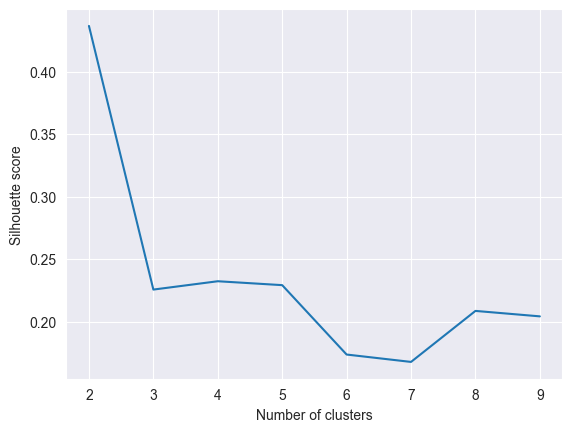

In [36]:
search_best_number_of_personae(features_scaled)

In [38]:
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(features_scaled)
selected_features['kmeans_label'] = labels
selected_features.head()

C:\Users\magda\AppData\Local\Temp\ipykernel_13700\2788476733.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_features['kmeans_label'] = labels


,persona,in_out_degree_ratio,betweenness,kcore,neutral_posts_ratio,negative_posts_ratio,posts_per_day,lifespan_median,survival_rate,avg_word_count,kmeans_label
user_id,,,,,,,,,,,
2,Persona_6,0.857143,5.842536e-05,19,0.000000,0.176471,1.70,NaN,1.000000,25.094118,0
3,Persona_5,0.200000,4.417667e-07,5,0.043478,0.000000,0.46,NaN,1.000000,30.956522,3
4,Persona_1,0.333333,1.648232e-04,19,0.012821,0.025641,1.56,NaN,1.000000,29.038462,3
5,Persona_3,0.992366,2.151160e-02,41,0.049785,0.059227,23.30,1.375000,0.935252,26.466953,2
6,Persona_6,0.677419,3.493630e-03,27,0.101010,0.126263,3.96,1.020833,0.937500,24.606061,0


In [39]:
selected_features['kmeans_label'].value_counts()

kmeans_label
3    478
0    385
2     59
1     32
Name: count, dtype: int64

In [42]:
selected_features.drop(columns=['persona'], inplace=False).groupby('kmeans_label').mean()

,in_out_degree_ratio,betweenness,kcore,neutral_posts_ratio,negative_posts_ratio,posts_per_day,lifespan_median,survival_rate,avg_word_count
kmeans_label,,,,,,,,,
0,0.952245,0.001261,21.823377,0.075252,0.138840,3.105506,0.500216,0.961268,27.088230
1,1.040796,0.003175,35.218750,0.067925,0.134151,7.047500,19.763021,0.954462,26.928261
2,1.068585,0.015681,41.000000,0.061625,0.097877,22.345424,5.132062,0.921672,25.906566
3,0.673716,0.000207,8.550209,0.023224,0.074809,0.761674,0.020136,0.996558,30.830881


### Compare with old personas

<Axes: xlabel='kmeans_label', ylabel='persona'>

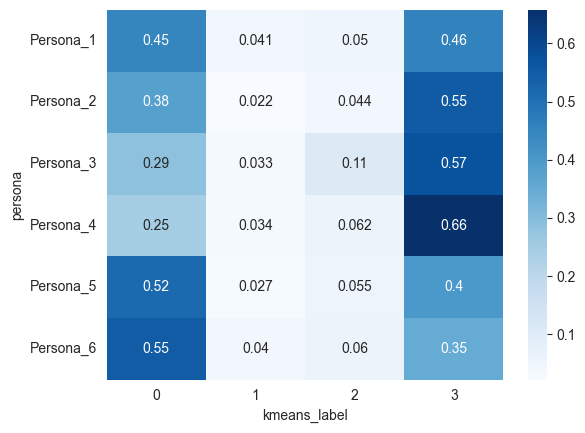

In [43]:
tab = pd.crosstab(selected_features['persona'], selected_features['kmeans_label'], normalize='index')
sns.heatmap(tab, annot=True, cmap='Blues')

<Axes: xlabel='kmeans_label', ylabel='persona'>

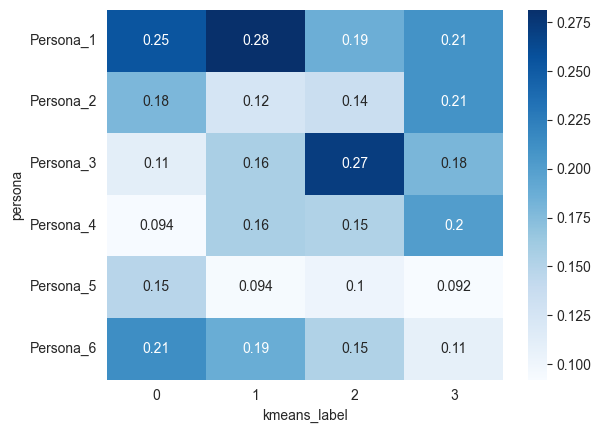

In [44]:
tab = pd.crosstab(selected_features['persona'], selected_features['kmeans_label'], normalize='columns')
sns.heatmap(tab, annot=True, cmap='Blues')

In [45]:
adjusted_rand_score(selected_features['persona'], selected_features['kmeans_label'])

0.013590364335674085

## Temporal stability of agents behaviour

In [ ]:
window = 5
days = [10, 20, 35, 50]